In [ ]:
from utils.loader import load_csv, load_json_folder, save_json
from utils.misc import filter_valid_folktales
from models.folktale import Folktale
from models.event import MIN_EVENTS
from utils.visualization import plot_genre_distribution, plot_nation_counts
import requests
import os
import time


In [36]:
data_dir = "./data"
folktales_csv = "folk_tales_deduplicated.csv"

processed_dir = os.path.join(data_dir, "processed")
processed_folktales = os.path.join(processed_dir, folktales_csv)

out_dir = "./out"

information_dir = "./information"


In [37]:
df = load_csv(processed_folktales)

print(df.columns)

df.describe()


Index(['Unnamed: 0', 'source', 'nation', 'title', 'text'], dtype='str')


,Unnamed: 0
count,2932.000000
mean,1467.908254
std,848.848684
min,0.000000
25%,732.750000
50%,1467.500000
75%,2203.250000
max,2937.000000


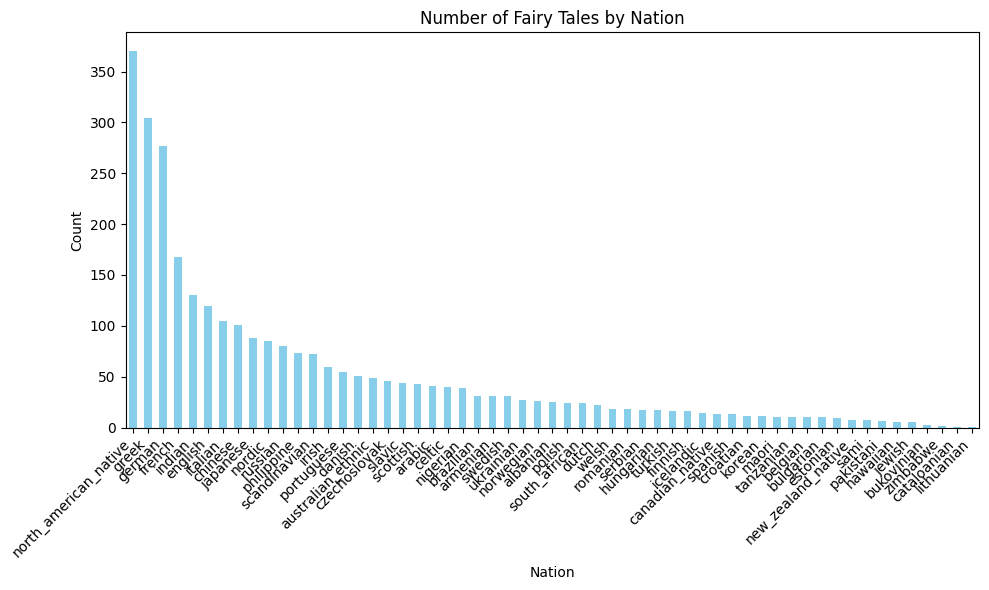

['japanese', 'serbian', 'german', 'french', 'north_american_native', 'brazilian', 'armenian', 'english', 'russian', 'greek', 'danish', 'canadian_native', 'ukrainian', 'indian', 'norwegian', 'welsh', 'scandinavian', 'polish', 'czechoslovak', 'scottish', 'celtic', 'portuguese', 'arabic', 'croatian', 'estonian', 'dutch', 'italian', 'nigerian', 'albanian', 'maori', 'nordic', 'irish', 'hungarian', 'south_african', 'slavic', 'australian_ethnic', 'chinese', 'tanzanian', 'swedish', 'icelandic', 'philippine', 'hawaiian', 'jewish', 'romanian', 'korean', 'turkish', 'finnish', 'belgian', 'spanish', 'cataloanian', 'bulgarian', 'bukovinian', 'new_zealand_native', 'sami', 'pakistani', 'lithuanian', 'zimbabwe']


In [38]:
nation = df["nation"]
plot_nation_counts(nation)

nations = list(nation.unique())
print(nations)

In [ ]:
folktales_json = load_json_folder(out_dir)
folktales = [Folktale(**folktale_json) for folktale_json in folktales_json.values()]
valid_folktales = filter_valid_folktales(folktales, MIN_EVENTS)


2026-04-06 19:31:08.688 | WARNING  | utils.misc:filter_valid_folktales:11 - 'The Peace with the Snakes' has too few events (0, minimum required: 3)
2026-04-06 19:31:08.690 | WARNING  | utils.misc:filter_valid_folktales:11 - 'Tawhaki' has too few events (1, minimum required: 3)
2026-04-06 19:31:08.690 | WARNING  | utils.misc:filter_valid_folktales:11 - 'The Old Dog' has too few events (1, minimum required: 3)
2026-04-06 19:31:08.691 | WARNING  | utils.misc:filter_valid_folktales:11 - 'Jack and the Beanstalk' has too few events (0, minimum required: 3)
2026-04-06 19:31:08.692 | WARNING  | utils.misc:filter_valid_folktales:11 - 'The King and the Ju Ju Tree' has too few events (1, minimum required: 3)
2026-04-06 19:31:08.692 | WARNING  | utils.misc:filter_valid_folktales:11 - 'The Peacock and Juno' has too few events (0, minimum required: 3)
2026-04-06 19:31:08.693 | WARNING  | utils.misc:filter_valid_folktales:11 - 'Weedah the Mocking Bird' has too few events (0, minimum required: 3)
2026

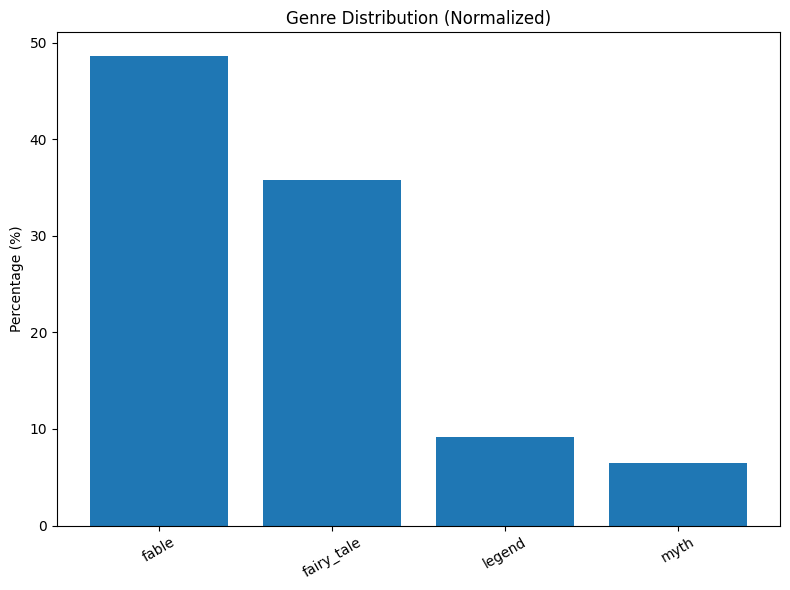

In [40]:
plot_genre_distribution(valid_folktales)


In [ ]:
nations_map = {
	"japanese": "Japanese_people",
	"serbian": "Serbs",
	"german": "Germans",
	"french": "French_people",
	"north_american_native": "Indigenous_peoples_of_the_Americas",
	"brazilian": "Brazilians",
	"armenian": "Armenians",
	"english": "English_people",
	"russian": "Russians",
	"greek": "Greeks",
	"danish": "Danes",
	"canadian_native": "Indigenous_peoples_in_Canada",
	"ukrainian": "Ukrainians",
	"indian": "Indian_people",
	"norwegian": "Norwegians",
	"welsh": "Welsh_people",
	"scandinavian": "Scandinavia",
	"polish": "Polish_people",
	"czechoslovak": "Czechoslovakia",
	"scottish": "Scottish_people",
	"celtic": "Celtic_peoples",
	"portuguese": "Portuguese_people",
	"arabic": "Arabs",
	"croatian": "Croats",
	"estonian": "Estonians",
	"dutch": "Dutch_people",
	"italian": "Italians",
	"nigerian": "Nigerians",
	"albanian": "Albanians",
	"maori": "Māori_people",
	"nordic": "Nordic_countries",
	"irish": "Irish_people",
	"hungarian": "Hungarians",
	"south_african": "South_Africans",
	"slavic": "Slavs",
	"australian_ethnic": "Ethnic_groups_in_Australia",
	"chinese": "Chinese_people",
	"tanzanian": "Tanzanians",
	"swedish": "Swedes",
	"icelandic": "Icelanders",
	"philippine": "Filipinos",
	"hawaiian": "Native_Hawaiians",
	"jewish": "Jews",
	"romanian": "Romanians",
	"korean": "Koreans",
	"turkish": "Turkish_people",
	"finnish": "Finns",
	"belgian": "Belgians",
	"spanish": "Spaniards",
	"cataloanian": "Catalans",
	"bulgarian": "Bulgarians",
	"bukovinian": "Bukovina",
	"new_zealand_native": "Māori_people",
	"sami": "Sami_people",
	"pakistani": "Pakistanis",
	"lithuanian": "Lithuanians",
	"zimbabwe": "Zimbabweans"
}

print(nations == list(nations_map.keys()))


True


In [42]:
def get_wiki_summary(label: str, wiki_pages_map: dict):
	page_title = wiki_pages_map.get(label)
	# https://zuplo.com/learning-center/wikipedia-api-guide
	url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{page_title}"
	# Información sobre el dispositivo consultante
	headers = {"User-Agent": "FolktaleDataBot/1.0 (example@example.com)"}
		
	try:
		response = requests.get(url, headers=headers, timeout=10)
		response.raise_for_status()
		data = response.json()
		
		return data.get("extract", "No summary available.")
	except requests.RequestException as e:
		return {"title": page_title, "error": str(e)}
	except ValueError:
		return {"title": page_title, "error": "Invalid JSON response from Wikipedia"}


In [ ]:
def fetch_wiki_summaries(labels: list, wiki_pages_map: dict):
    # Información sobre el dispositivo consultante
    headers = {"User-Agent": "FolktaleDataBot/1.0 (example@example.com)"}
    summaries = {}
    
    for label in labels:
        page_title = wiki_pages_map.get(label)
        
        # https://zuplo.com/learning-center/wikipedia-api-guide
        url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{page_title}"
        
        try:
            response = requests.get(url, headers=headers, timeout=10)
            response.raise_for_status()
            data = response.json()
            summaries[label] = data.get("extract", "No summary available.")
        except requests.RequestException as e:
            summaries[label] = {"title": page_title, "error": str(e)}
        except ValueError:
            summaries[label] = {"title": page_title, "error": "Invalid JSON response from Wikipedia"}

        time.sleep(0.5)

    return summaries

In [52]:
nations_summaries = fetch_wiki_summaries(nations, nations_map)
	

In [53]:
for label, summary in nations_summaries.items():
    print(f"{label.upper()}:\n{summary}\n")

nations_path = os.path.join(information_dir, "nations.json")
save_json(nations_path, nations_summaries)


JAPANESE:
Japanese people  are people or ethnic groups identified with the Japanese archipelago. Japanese people constitute 97.1% of the population of the country of Japan. Approximately 119.9 million Japanese people are residents of Japan, and there are approximately five million members of the Japanese diaspora, known as Nikkeijin (日系人).

SERBIAN:
The Serbs are a South Slavic ethnic group and nation who share a common Serbian ancestry, culture, history, and language. They primarily live in their nation-state of Serbia, and in neighboring Bosnia and Herzegovina, Montenegro, Croatia, and Kosovo, with smaller communities in North Macedonia, Romania, and Hungary. They also constitute a significant diaspora with communities across Europe, the Americas, and Oceania.

GERMAN:
Germans are the natives or inhabitants of Germany, or sometimes more broadly any people who are of German descent or native speakers of the German language. The constitution of Germany, implemented in 1949 following th

In [54]:
traits_map = {
	"openness": "Openness_to_experience",
	"conscientiousness": "Conscientiousness",
	"extraversion": "Extraversion_and_introversion",
	"agreeableness": "Agreeableness",
	"neuroticism": "Neuroticism"
}


In [55]:
traits_summaries = fetch_wiki_summaries(list(traits_map.keys()), traits_map)
	

In [56]:
for label, summary in traits_summaries.items():
    print(f"{label.upper()}:\n{summary}\n")

traits_path = os.path.join(information_dir, "traits.json")
save_json(traits_path, traits_summaries)


OPENNESS:
Openness to experience is one of the domains which are used to describe human personality in the Five Factor Model. Openness involves six facets, or dimensions: active imagination (fantasy), aesthetic sensitivity, attentiveness to inner feelings, preference for variety (adventurousness), intellectual curiosity, and challenging authority. A great deal of psychometric research has demonstrated that these facets or qualities are significantly correlated. Thus, openness can be viewed as a global personality trait consisting of a set of specific traits, habits, and tendencies that cluster together.

CONSCIENTIOUSNESS:
Conscientiousness is the personality trait of being responsible, careful, or diligent. Conscientiousness implies a desire to do a task well, and to take obligations to others seriously. Conscientious people tend to be efficient and organized as opposed to easy-going and disorderly. They tend to show self-discipline, act dutifully, and aim for achievement; they displa